# Comparing two versions of EoMT
One trained on the Cityscapes dataset, another one on the COCO

## Setup

In [ ]:
###########################################################
# Run this cell only if you run the notebook on the Colab #
###########################################################

import os

repo_url = "https://github.com/timmfy/MaskArchitectureAnomaly_CourseProject.git"
repo_dir = "/content/MaskArchitectureAnomaly_CourseProject"

if not os.path.exists(repo_dir):
    !git clone {repo_url} {repo_dir}

%cd /content/MaskArchitectureAnomaly_CourseProject

# Install the libraries
!pip install -r requirements.txt

# Mount the drive with the model weights and the cityscapes validation dataset
from google.colab import drive
drive.mount('/content/drive')

/content/MaskArchitectureAnomaly_CourseProject
Mounted at /content/drive


In [11]:
################################
# Change the paths accordingly #
################################

dataset_path = "/content/drive/MyDrive/FAI_Project/CityScapesDataset"
finetuned_models_path = "/content/drive/MyDrive/FAI_Project/checkpoints/"
pretrained_models_path = "/content/drive/MyDrive/CourseProjectAnomaly/"

In [12]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np

# Add root and eomt to path
root_path = os.path.abspath(".")
if root_path not in sys.path:
    sys.path.insert(0, root_path)

import eomt_setup
import eomt_inference

device = eomt_setup.setup_environment(eomt_path="eomt")

img_idx = 0 # Visualize the first image in the dataset
config_path_cityscapes = "eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
config_path_coco = "eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_coco_interpolated = "eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x_finetuning.yaml"
weights_path_cityscapes_pretrained = pretrained_models_path + "eomt_cityscapes.bin"
weights_path_coco_pretrained = pretrained_models_path + "eomt_coco.bin"
weights_path_coco_finetuned_backbone_frozen = finetuned_models_path + "backbone_frozen_24_epochs.ckpt"
weights_path_coco_finetuned_backbone_unfrozen = finetuned_models_path + "backbone_unfrozen_10_50_epochs.ckpt"
weights_path_coco_finetuned_backbone_unfrozen_interpolated = finetuned_models_path + "backbone_unfrozen_interpolation_10_45_epochs.ckpt"

IGNORE_INDEX = 255

## 1. CityScapes EoMT (Semantic Segmentation)
First, we load the model trained on CityScapes and run semantic inference.

Loading Cityscapes Model...
Loading checkpoint from /content/drive/MyDrive/CourseProjectAnomaly/eomt_cityscapes.bin with weights_only=True
Loaded weights from /content/drive/MyDrive/CourseProjectAnomaly/eomt_cityscapes.bin


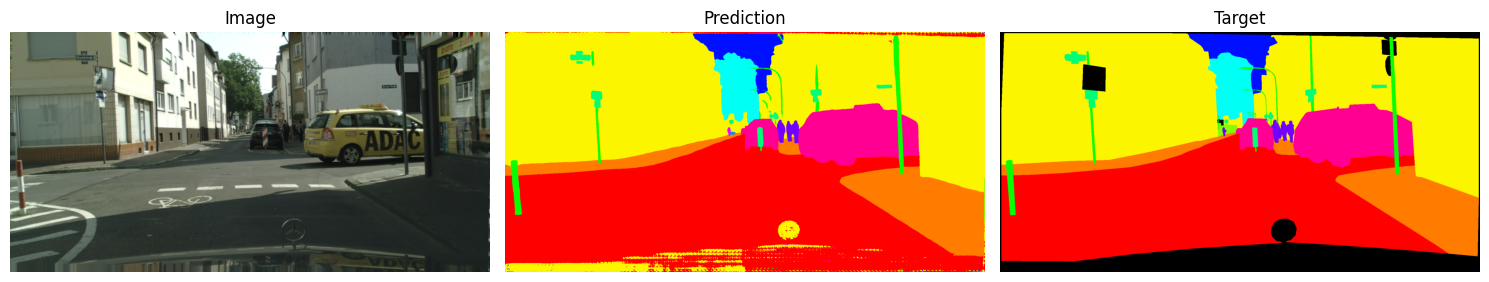

In [13]:
print("Loading Cityscapes Model...")
config_cs = eomt_setup.load_config(config_path_cityscapes)
data_cs = eomt_setup.setup_data(config_cs, data_path=dataset_path)
model_cs = eomt_setup.load_model(config_cs, data_cs, device, weights_path=weights_path_cityscapes_pretrained)

img, target = data_cs.val_dataloader().dataset[img_idx]
pred_array, target_array = eomt_inference.infer_semantic(model_cs, img, target, device, data_cs.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, pred_array, target_array, IGNORE_INDEX)

## 2. COCO EoMT (Panoptic Segmentation)
Next, we load the model trained on COCO and run panoptic inference.
Note: This model can also perform semantic inference.

Loading COCO Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading checkpoint from /content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin with weights_only=True
Loaded weights from /content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin


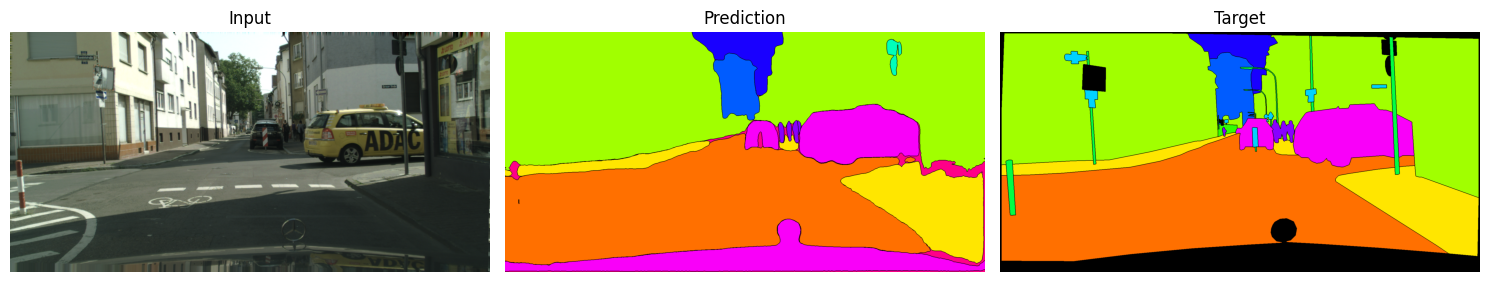

In [6]:
import importlib
importlib.reload(eomt_setup)
importlib.reload(eomt_inference)

print("Loading COCO Model...")
config_coco = eomt_setup.load_config(config_path_coco)
data_coco = eomt_setup.setup_data(config_coco, data_path=dataset_path)

cpu_device = torch.device("cpu")
model_coco = eomt_setup.load_model(config_coco, data_coco, cpu_device, weights_path=weights_path_coco_pretrained)
model_coco = model_coco.to(device=device, dtype=torch.float32)

img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = eomt_inference.infer_panoptic(model_coco, img, target, device)
# Map COCO semantic predictions to Cityscapes train IDs for color consistency
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_panoptic_results(model_coco, img, sem_pred, inst_pred, sem_target, inst_target)

## 3. COCO EoMT (Semantic Segmentation)
Running semantic inference with the COCO model on the same Cityscapes image.

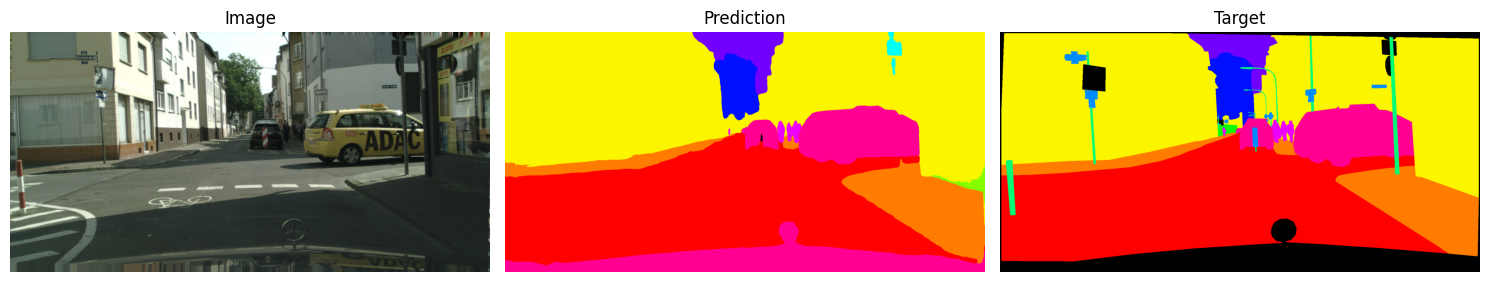

In [ ]:
img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, sem_target = eomt_inference.infer_semantic(model_coco, img, target, device, data_coco.img_size, IGNORE_INDEX)
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_semantic_results(img, sem_pred, sem_target, IGNORE_INDEX)

## 4. Evaluation of the pretrained models on the validation dataset

In [ ]:
print(f"Evaluating the COCO model...")
coco_mIoU, coco_ious = eomt_inference.evaluate_semantic(model_coco, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=255, is_coco=True)

Evaluating the COCO model...


In [ ]:
print(f"Evaluating the CityScapes model...")
cityscapes_mIoU, cityscapes_ious = eomt_inference.evaluate_semantic(model_cs, data_cs.val_dataloader(), device, data_cs.img_size, num_classes=19, ignore_index=255, is_coco=False)

Evaluating the CityScapes model...


In [ ]:
print("CityScapes Results:")
print(f"mIoU: {cityscapes_mIoU}")
print(f"IoUs: {cityscapes_ious}")
print("COCO Results:")
print(f"mIoU: {coco_mIoU}")
print(f"IoUs: {coco_ious}")

CityScapes Results:
mIoU: 0.8167984280883135
IoUs: tensor([0.9840, 0.8736, 0.9415, 0.6607, 0.6549, 0.7104, 0.7500, 0.8213, 0.9302,
        0.6660, 0.9554, 0.8538, 0.7111, 0.9554, 0.8179, 0.9032, 0.7736, 0.7435,
        0.8127], dtype=torch.float64)
COCO Results:
mIoU: 0.5175487123893245
IoUs: tensor([0.9401, 0.6474, 0.8404, 0.4577, 0.4809, 0.0000, 0.6037, 0.0441, 0.8507,
        0.0581, 0.8970, 0.6722, 0.0000, 0.8422, 0.2934, 0.7116, 0.1361, 0.6359,
        0.7220], dtype=torch.float64)


## 5. Visual Comparison of Finetuned Models
Now we visualize the predictions of the three

### 5.1 Finetuned with the Backbone Frozen
We load the models and run inference on a sample image from the Cityscapes validation set.

Visualizing Finetuned (Frozen Backbone)...
Loading checkpoint from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_frozen_24_epochs.ckpt with weights_only=True
Loaded weights from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_frozen_24_epochs.ckpt


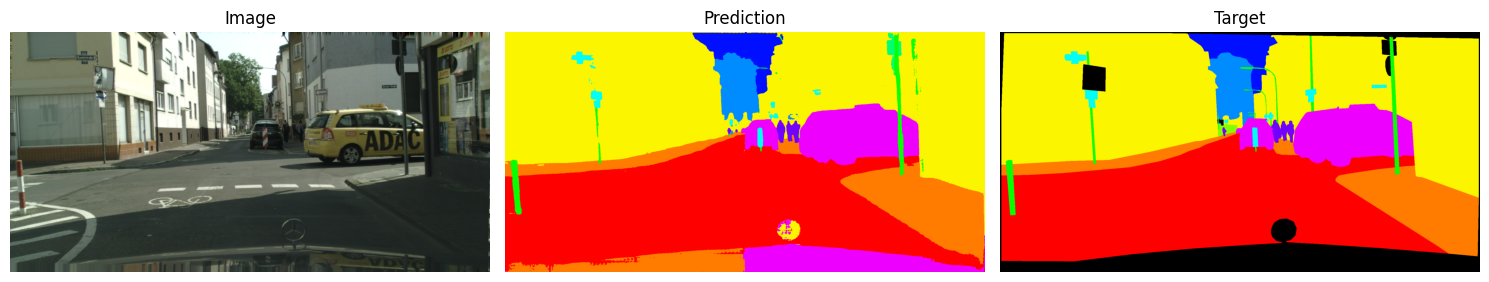

In [25]:
print("Visualizing Finetuned (Frozen Backbone)...")
config_frozen = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_frozen, data_path=dataset_path)
model_frozen = eomt_setup.load_model(config_frozen, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_frozen)

img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred_frozen, sem_target = eomt_inference.infer_semantic(model_frozen, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_frozen, sem_target, IGNORE_INDEX)

### 5.2 Finetuned with the Backbone Unfrozen

Visualizing Finetuned (Unfrozen Backbone)...
Loading checkpoint from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_unfrozen_10_50_epochs.ckpt with weights_only=True
Loaded weights from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_unfrozen_10_50_epochs.ckpt


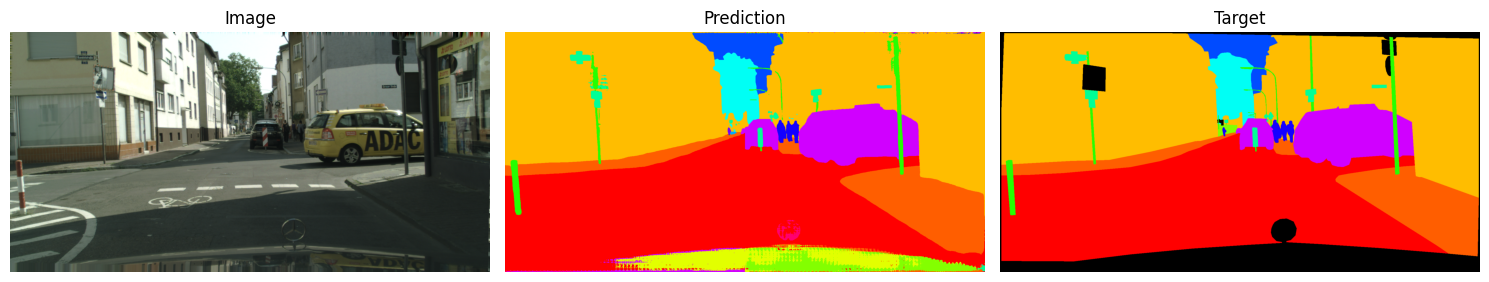

In [23]:
print("Visualizing Finetuned (Unfrozen Backbone)...")
config_unfrozen = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_unfrozen, data_path=dataset_path)
model_unfrozen = eomt_setup.load_model(config_unfrozen, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_unfrozen)

sem_pred_unfrozen, _ = eomt_inference.infer_semantic(model_unfrozen, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_unfrozen, sem_target, IGNORE_INDEX)

### 5.3 Finetuned with the Backbone Unfrozen + Interpolation

Visualizing Finetuned (Interpolated)...
Loading checkpoint from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_unfrozen_interpolation_10_45_epochs.ckpt with weights_only=True
Loaded weights from /content/drive/MyDrive/FAI_Project/checkpoints/backbone_unfrozen_interpolation_10_45_epochs.ckpt


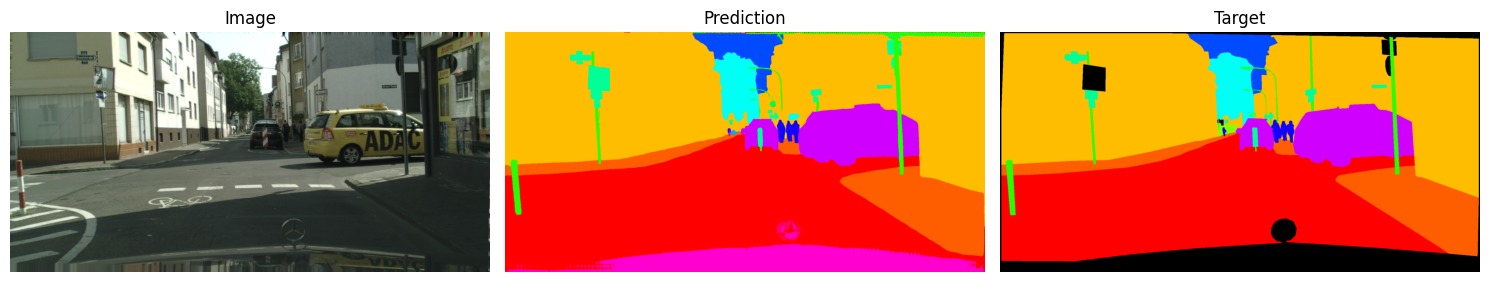

In [26]:
print("Visualizing Finetuned (Interpolated)...")
config_interp = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_interp, data_path=dataset_path)
model_interp = eomt_setup.load_model(config_interp, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_unfrozen_interpolated)

sem_pred_interp, _ = eomt_inference.infer_semantic(model_interp, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_interp, sem_target, IGNORE_INDEX)

## 6. Evaluation of the finetuned models on the validation dataset

In [28]:
print("Evaluating Finetuned Model (Backbone Frozen)...")
frozen_mIoU, frozen_ious = eomt_inference.evaluate_semantic(model_frozen, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Frozen Backbone mIoU: {frozen_mIoU}")

Evaluating Finetuned Model (Backbone Frozen)...
Frozen Backbone mIoU: 0.742211286781708


In [29]:
print(f"Frozen Backbone IoUs: {frozen_ious}")

Frozen Backbone IoUs: tensor([0.9757, 0.8094, 0.9179, 0.5741, 0.5559, 0.5631, 0.6649, 0.7222, 0.9162,
        0.6431, 0.9492, 0.8102, 0.5377, 0.9376, 0.7054, 0.7821, 0.5805, 0.6707,
        0.7861], dtype=torch.float64)


In [30]:
print("Evaluating Finetuned Model (Backbone Unfrozen)...")
unfrozen_mIoU, unfrozen_ious = eomt_inference.evaluate_semantic(model_unfrozen, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Unfrozen Backbone mIoU: {unfrozen_mIoU}")
print(f"Unfrozen Backbone IoUs: {unfrozen_ious}")

Evaluating Finetuned Model (Backbone Unfrozen)...
Unfrozen Backbone mIoU: 0.7897917874581339
Unfrozen Backbone IoUs: tensor([0.9823, 0.8644, 0.9351, 0.5728, 0.6324, 0.6845, 0.7377, 0.7866, 0.9306,
        0.6561, 0.9556, 0.8494, 0.6804, 0.9437, 0.7149, 0.8740, 0.7067, 0.7009,
        0.7980], dtype=torch.float64)


In [32]:
print("Evaluating Finetuned Model (Backbone Unfrozen + Interpolation)...")
interp_mIoU, interp_ious = eomt_inference.evaluate_semantic(model_interp, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Interpolated Model mIoU: {interp_mIoU}")
print(f"Interpolated Model IoUs: {interp_ious}")

Evaluating Finetuned Model (Backbone Unfrozen + Interpolation)...
Interpolated Model mIoU: 0.8135687159046758
Interpolated Model IoUs: tensor([0.9828, 0.8648, 0.9393, 0.6319, 0.6511, 0.7109, 0.7539, 0.8004, 0.9318,
        0.6690, 0.9582, 0.8581, 0.7095, 0.9577, 0.8776, 0.8811, 0.7459, 0.7277,
        0.8064], dtype=torch.float64)
